# COSC2673 | COSC2793 (Computational) Machine Learning

# Assignment 1 

Name: Vadhthanak Vibol 
ID: s3951117

Due date and time: Wednesday, 15 April 2026, 11:59 pm AET (Week 6).

In [1]:
# Importing section

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

## Data Preparation

Load in Data for pandas to read the dataset

In [2]:
# Load data

train = pd.read_csv('./dataset/train_data.csv')
test = pd.read_csv('./dataset/test_data.csv')

## Exploratory Data Analysis

The brief data analysis will happen here where we will briefly compare the frequency of the AirBnB properties

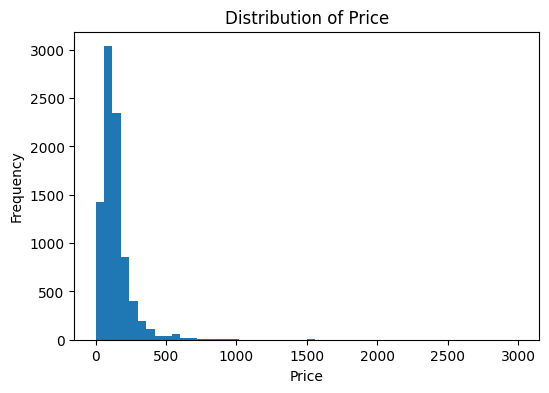

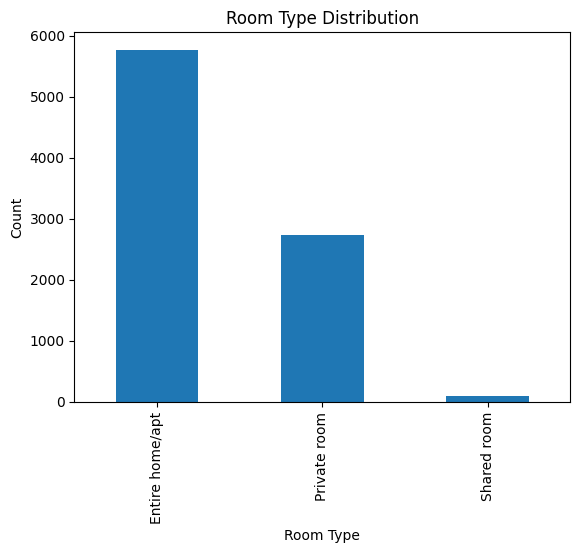

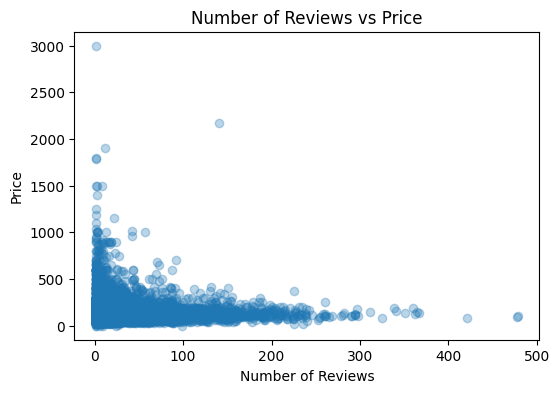

In [3]:
# Distribution of price
plt.figure(figsize=(6,4))
plt.hist(train["price"], bins=50)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


# Room type distribution
train["room_type"].value_counts().plot(kind='bar')
plt.title("Room Type Distribution")
plt.xlabel("Room Type")
plt.ylabel("Count")
plt.show()


# Reviews vs price
plt.figure(figsize=(6,4))
plt.scatter(train["number_of_reviews"], train["price"], alpha=0.3)
plt.title("Number of Reviews vs Price")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.show()

The distribution of price is highly skewed, with a few very high values. This suggests the presence of outliers, which may negatively affect model performance.

The price distribution is highly skewed to the lower end of the graph.
This supports the use of log transformation to improve model performance.

In [4]:
# Drop the country column
train = train.drop('country', axis=1)
test = test.drop('country', axis=1)

# Convert boolean columns
for col in ["host_is_superhost", "instant_bookable"]:
    train[col] = train[col].map({"t": 1, "f": 0})
    test[col] = test[col].map({"t": 1, "f": 0})

Removing unecessary columns and convert true/false columns to 1s and 0s to make data readable

In [5]:
y = train["price"]
X = train.drop(columns=["price"])

## Model Performance Before Preprocessing

In [6]:
# ========================
# BEFORE PREPROCESSING
# ========================

# Split X and y
y_raw = train["price"]
X_raw = train.drop(columns=["price"])

# One-hot encoding
X_raw = pd.get_dummies(X_raw, columns=["city", "room_type"])

# Train-validation split
X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# Models
models_before = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(alpha=0.1)
}

results_before = {}

for name, model in models_before.items():
    model.fit(X_train_b, y_train_b)
    y_pred = model.predict(X_val_b)

    results_before[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_val_b, y_pred)),
        "MAE": mean_absolute_error(y_val_b, y_pred),
        "R2": r2_score(y_val_b, y_pred)
    }

results_df_before = pd.DataFrame(results_before).T
results_df_before

,RMSE,MAE,R2
Linear,103.683616,47.816145,0.395486
Ridge,103.669416,47.713224,0.395651
Lasso,103.614379,47.220241,0.396293


### R2 Analysis

Before preprocessing the model data is messy and scattered making the Coefficient of Determination low and the graph will be underfitting. If the model were to be chosen it would be a Lasso Regression training model since it has the highest Coefficient of Determination amongst others

## Model Performance After Preprocessing

In [7]:
# ========================
# AFTER PREPROCESSING
# ========================

# Remove outliers
train_clean = train[train["price"] < train["price"].quantile(0.99)]

# Split X and y
y = train_clean["price"]
X = train_clean.drop(columns=["price"])

# Log transform
y = np.log1p(y)

# One-hot encoding
X = pd.get_dummies(X, columns=["city", "room_type"])

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale after split
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Models
models_after = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(alpha=0.1)
}

results_after = {}

for name, model in models_after.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    results_after[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_val, y_pred)),
        "MAE": mean_absolute_error(y_val, y_pred),
        "R2": r2_score(y_val, y_pred)
    }

results_df_after = pd.DataFrame(results_after).T
results_df_after

,RMSE,MAE,R2
Linear,0.350451,0.261792,0.647628
Ridge,0.350449,0.261791,0.647634
Lasso,0.394810,0.300445,0.552779


### R2 Analysis

After thoroughly preprocessing data, it has become much more clean and structured helping the model train better and the data to be modeled to be much better structured to be used.

In a turn of events, the R2 numbers are two times higher making it a better fitting model to train, where the Ridge Regression model beats Linear Regression model by a hair by having a Coefficient of Determination higher than Linear.

Being the better model, it will be used as the training model to be more accurate with predcitions.

### Data Distribution After Preprocessing


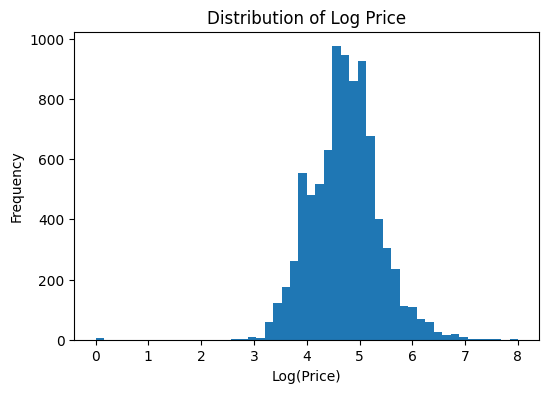

In [8]:
plt.figure(figsize=(6,4))
plt.hist(np.log1p(train["price"]), bins=50)
plt.title("Distribution of Log Price")
plt.xlabel("Log(Price)")
plt.ylabel("Frequency")
plt.show()

## Comparison of Results

Comparision of the two before and after preprocessing grouped up into one single box

Ridge regression performed best due to better generalisation from regularisation.

In [9]:
before_df = results_df_before.copy()
after_df = results_df_after.copy()

before_df["Stage"] = "Before"
after_df["Stage"] = "After"

comparison = pd.concat([before_df, after_df])
comparison

,RMSE,MAE,R2,Stage
Linear,103.683616,47.816145,0.395486,Before
Ridge,103.669416,47.713224,0.395651,Before
Lasso,103.614379,47.220241,0.396293,Before
Linear,0.350451,0.261792,0.647628,After
Ridge,0.350449,0.261791,0.647634,After
Lasso,0.394810,0.300445,0.552779,After


## Final Selection

Comparing the two results we can see that after a much needed preprocessing on the data as raw data is often noisy, inconsistent, incomplete, or incorrectly formatted for machine learning models. The data is more consistent with trends and is easier to model with a better fitting line.

Ridge regression is chosen for the training model as it has the best fit as R2 is the highest compared to others after preprocessing.

In [10]:
# Ridge Regression Model Training

# Clean data again
train_clean = train[train["price"] < train["price"].quantile(0.99)]

# Create a new X and y for training
y_final = np.log1p(train_clean["price"])
X_final = train_clean.drop(columns=["price"])

# One hot encoding
X_final = pd.get_dummies(X_final, columns=["city", "room_type"])
test_processed = pd.get_dummies(test, columns=["city", "room_type"])

# Match columns
X_final, test_processed = X_final.align(test_processed, join='left', axis=1, fill_value=0)

# Scale
scaler = StandardScaler()
X_final_scaled = scaler.fit_transform(X_final)
test_scaled = scaler.transform(test_processed)

# Train final Ridge model
final_model = Ridge()
final_model.fit(X_final_scaled, y_final)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [11]:
# Predict test data
test_pred = final_model.predict(test_scaled)

# Convert back from log scale
test_pred = np.expm1(test_pred)

test_pred[:10]

array([ 48.19522802, 127.37691938,  63.45233416,  46.55427327,
        69.25519401,  59.86444025, 156.85232499, 132.29559491,
        62.88941821, 135.56553731])

In [12]:
submission = pd.DataFrame({
    "price": test_pred
})

submission.to_csv("s3951117_predictions.csv", index=False)

In [13]:
submission.head()

,price
0,48.195228
1,127.376919
2,63.452334
3,46.554273
4,69.255194


## Final Model Training - Ridge

In [14]:
# Cleaning Data
train_clean = train[train["price"] < train["price"].quantile(0.99)]

y = np.log1p(train_clean["price"])
X = train_clean.drop(columns=["price"])

X = pd.get_dummies(X, columns=["city", "room_type"])
test_processed = pd.get_dummies(test, columns=["city", "room_type"])

# Make columns match
X, test_processed = X.align(test_processed, join='left', axis=1, fill_value=0)

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X)
test_scaled = scaler.transform(test_processed)

# Train final model
final_model = Ridge()
final_model.fit(X, y)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


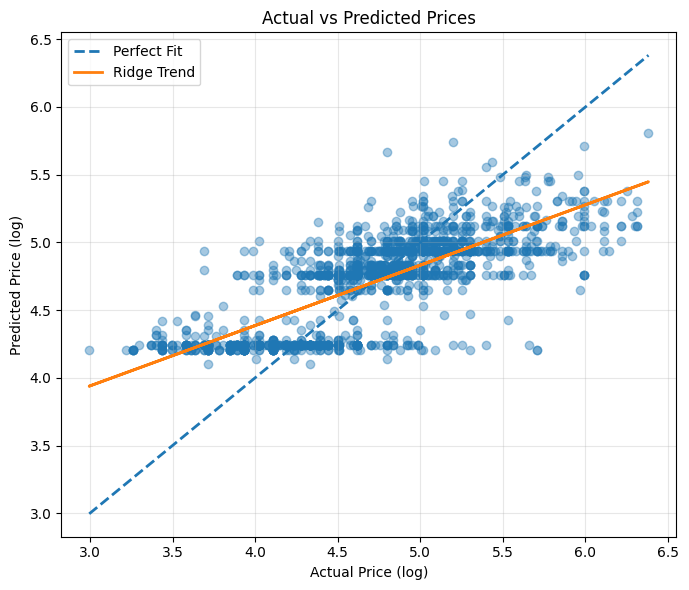

In [15]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

# Scatter
plt.scatter(y_val, y_pred, alpha=0.4)

# Perfect line (y = x)
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle='--',
    linewidth=2,
    label='Perfect Fit'
)

# Ridge trend line
m, b = np.polyfit(y_val, y_pred, 1)
plt.plot(
    y_val,
    m*y_val + b,
    linewidth=2,
    label='Ridge Trend'
)

plt.xlabel("Actual Price (log)")
plt.ylabel("Predicted Price (log)")
plt.title("Actual vs Predicted Prices")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The model may not capture all real-world factors such as property condition or seasonal demand.